In [1]:
import math
import json
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
import sys
from typing import List, Dict
from pypalettes import load_palette
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[1] / "src"))

from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.riczne import RichardsonZne
from nbutils.lsf_zne_hill import *
from nbutils.data_loader import load_all_experiments

from nbutils.lsf_zne import *

#### Plot markup settting

In [2]:
plt.rcParams.update({
    "font.family": "serif",
    #"font.serif": "Computer Modern Roman",
    "font.size": 10,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "legend.frameon": False,
})

---

### Load experimental data

In [3]:
# ==========================================
# Recursive experiment loader
# ==========================================

def load_all_experiments(data_root):
    """
    Recursively load all experiments under data_root and
    populate a master data_records dictionary.

    Parameters
    ----------
    data_root : str or Path
        Root directory containing experiment folders (e.g. data/)

    Returns
    -------
    data_records : dict
        Master experiment registry
    """
    data_root = Path(data_root)
    data_records = {}

    # Iterate over subdirectories like c0, c0.01, ...
    for exp_dir in sorted(p for p in data_root.iterdir() if p.is_dir()):
        experiment_id = exp_dir.name

        json_files = sorted(exp_dir.rglob("iter_*.json"))
        if not json_files:
            continue  # skip empty folders

        # --------------------------
        # Load and group raw data
        # --------------------------
        raw_groups = {}
        exact_solution = None

        for jf in json_files:
            with open(jf, "r") as f:
                data = json.load(f)

            t_max = data["config"]["ansatz"]["ugate"]["time"]["max"]
            cost = data["output"]["optimized_minimum_cost"][0]

            if exact_solution is None:
                exact_solution = data["output"].get("exact_sol", None)

            raw_groups.setdefault(t_max, []).append(cost)

        # --------------------------
        # Processed arrays
        # --------------------------
        t_vals = np.array(sorted(raw_groups.keys()))
        vqe_means = np.array([np.mean(raw_groups[t]) for t in t_vals])
        vqe_stds = np.array([np.std(raw_groups[t]) for t in t_vals])

        # --------------------------
        # Register experiment
        # --------------------------
        data_records[experiment_id] = {
            "meta": {
                "experiment_id": experiment_id,
                "data_path": str(exp_dir),
                "num_json_files": len(json_files),
                "noise_level": float(experiment_id.replace("c", "")) if experiment_id.startswith("c") else None,
            },

            "raw": {
                "json_files": [str(f) for f in json_files],
                "grouped_costs": raw_groups,
            },

            "processed": {
                "t_max": t_vals,
                "vqe_means": vqe_means,
                "vqe_stds": vqe_stds,
                "exact_solution": exact_solution,
            },

        }

    return data_records

### Data container

In [4]:
data_records = load_all_experiments("data-totalz")

In [5]:
# ==========================================
# DATA EXTRACTION
# ==========================================
data_dir = Path("data-totalz/VQE_Experiment_q5_l20_c0.0_delt0.1_20260220_152101")
json_files = sorted(data_dir.rglob("iter_*.json"))

raw_groups, exact_sol = {}, None
for f in json_files:
    with open(f, "r") as file:
        data = json.load(file)
        big_t = data["config"]["ansatz"]["ugate"]["time"]["max"]
        cost = data["output"]["optimized_minimum_cost"][0]
        #if exact_sol is None: exact_sol = data["output"]["exact_sol"]
        if big_t not in raw_groups: raw_groups[big_t] = []
        raw_groups[big_t].append(cost)

EXPERIMENTAL_PROCESSED_DATA = [[(np.mean(raw_groups[t]), np.std(raw_groups[t])), t] for t in sorted(raw_groups.keys())]
print(f"Len: {len(EXPERIMENTAL_PROCESSED_DATA)}")
print(f"Extracted data for {EXPERIMENTAL_PROCESSED_DATA} noise levels.")

Len: 0
Extracted data for [] noise levels.


In [6]:
#LSF_WINDOWS = [(10, 40), (10, 50), (10, 60), (10, 70), (10, 80), (10, 90), (10, 100)]
LSF_WINDOWS = [(0, 30), (0,40), (0, 50)]
EXACT_SOLUTION = -6.026674183332271
print("EXACT_SOLUTION =", EXACT_SOLUTION)

EXACT_SOLUTION = -6.026674183332271


In [8]:
# Extracting components
vqe_means_c0 = data_records["c0"]["processed"]["vqe_means"]
vqe_stds_c0 = data_records["c0"]["processed"]["vqe_stds"]
noise_levels_c0 = data_records["c0"]["processed"]["t_max"]

print(f"Loaded {len(noise_levels_c0)} data points.")
print("EXACT_SOLUTION =", EXACT_SOLUTION)

Loaded 101 data points.
EXACT_SOLUTION = -6.026674183332271


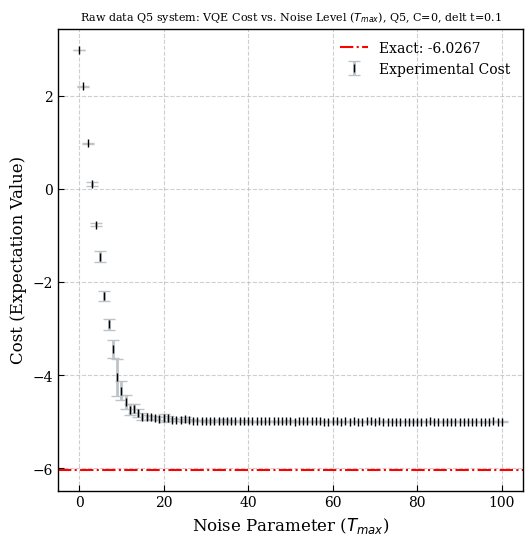

In [9]:
# Create a single clear plot
plt.figure(figsize=(6, 6))
plt.errorbar(noise_levels_c0, vqe_means_c0, yerr=vqe_stds_c0, fmt='|', color='black', 
             ecolor='#bdc3c7', elinewidth=2, capsize=4, markersize=6, 
             label='Experimental Cost')

plt.axhline(y=EXACT_SOLUTION, color='red', linestyle='-.', label=f'Exact: {EXACT_SOLUTION:.4f}')
# Aesthetic improvements
plt.title("Raw data Q5 system: VQE Cost vs. Noise Level ($T_{max}$), Q5, C=0, delt t=0.1", fontsize=8)
plt.xlabel("Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save the plot (if in a script) or show (if in a notebook)
#plt.savefig('raw_data_trend.png')
plt.show()

---

### $n$ from noise-free $C=0$ in $T_{max}$ range [0, 30]

In [10]:
# Noiseless guesses
ZNE_GUESS_NOISELESS = -5.0
A0_GUESS_NOISELESS = 10.0
T0_GUESS_NOISELESS = 8.0

In [11]:
"""
Extract experimental data.

Definitions:
    t        → T_max (noise scaling parameter)
    y        → measured energy
    sigma    → standard deviation (optional)
"""
mask = 31
t = noise_levels_c0[:mask]          # T_max
y = vqe_means_c0[:mask]
std_wt = 0.01
sigma = std_wt + vqe_stds_c0[:mask]

"""
Fixed Hill exponents to test.
"""

n_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Initial guess for fitted parameters:
#   p0[0] = ZNE → zero-noise extrapolated energy
#   p0[1] = A0  → amplitude = f(0) - ZNE (must be positive)
#   p0[2] = T0  → characteristic noise scale
#   p0 = [ZNE_guess, A0_guess, T0_guess]

# Guesses for noise-free data hill fitting
ZNE_GUESS_NOISELESS = -5.0
A0_GUESS_NOISELESS = 10.0

T0_GUESS_NOISELESS = 8.0
p0 = [ZNE_GUESS_NOISELESS, A0_GUESS_NOISELESS, T0_GUESS_NOISELESS]

bounds = (
    [-10.0, 0.0, 0],
    [-1.0, 20.0, 50.0],
)

fit_results = {}
for n in n_values:

    result_fit_hill_noiseless_across_n = fit_hill_noiseless(
        t=t,
        y=y,
        sigma=sigma,
        n=n,
        p0=p0,
        bounds=bounds,
        xtol=1e-10,
        ftol=1e-10,
        gtol=1e-10,
        max_nfev=5000,
    )

    ZNE, A0, T0 = result_fit_hill_noiseless_across_n["output"]["popt"]
    pcov = result_fit_hill_noiseless_across_n["output"]["pcov"]

    y_fit = hill(t=t, ZNE=ZNE, A=A0, T0=T0, n=n)
    residuals = y - y_fit

    LS = np.sum((residuals / sigma) ** 2)
    dof = len(y) - 3
    LS_red = LS / dof

    # Store results in dictionary
    fit_results[n] = {
        "initial_guess": {"ZNE0": p0[0], "A0_0": p0[1], "T0_0": p0[2]},
        "params": {"ZNE": ZNE, "A0": A0, "T0": T0},
        "LS": LS_red,
    }
# --- Print Summary Table ---
print(f"T_max range [0, 30]: {t}\n\n")
print(
    f"{'n':>2} | "
    f"{'ZNE_init':>9} | {'A0_init':>9} | {'T0_init':>8} || "
    f"{'ZNE_fit':>9} | {'A0_fit':>9} | {'T0_fit':>8} | "
    f"{'LS':>8}"
)
print("-" * 96)

for n, res in fit_results.items():
    ig = res["initial_guess"]
    p  = res["params"]

    print(
        f"{n:2d} | "
        f"{ig['ZNE0']:9.3f} | "
        f"{ig['A0_0']:9.3f} | "
        f"{ig['T0_0']:8.2f} || "
        f"{p['ZNE']:9.4f} | "
        f"{p['A0']:9.4f} | "
        f"{p['T0']:8.2f} | "
        f"{res['LS']:8.3f}"
    )

T_max range [0, 30]: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30]


 n |  ZNE_init |   A0_init |  T0_init ||   ZNE_fit |    A0_fit |   T0_fit |       LS
------------------------------------------------------------------------------------------------
 1 |    -5.000 |    10.000 |     8.00 ||   -7.2218 |   10.3104 |     7.00 |   82.723
 2 |    -5.000 |    10.000 |     8.00 ||   -5.1426 |    8.0862 |     3.74 |   20.416
 3 |    -5.000 |    10.000 |     8.00 ||   -4.9451 |    7.7722 |     3.34 |  104.579
 4 |    -5.000 |    10.000 |     8.00 ||   -4.8999 |    7.6269 |     3.24 |  214.765
 5 |    -5.000 |    10.000 |     8.00 ||   -4.9008 |    7.4924 |     3.46 |  318.699
 6 |    -5.000 |    10.000 |     8.00 ||   -4.9192 |    7.4070 |     3.83 |  384.292
 7 |    -5.000 |    10.000 |     8.00 ||   -4.9231 |    7.3713 |     3.98 |  420.733
 8 |    -5.000 |    10.000 |     8.00 ||   -4.9234 |    7.3522 |     4.04 |  443.455
 9 |    -5.000 |   

In [12]:
BEST_n_FROM_C0  = 2
######################################################################
BEST_T0_FROM_C0 = fit_results[BEST_n_FROM_C0]["params"]["T0"]
BEST_A0_FROM_C0 = fit_results[BEST_n_FROM_C0]["params"]["A0"]
ZNE_c0_best = fit_results[BEST_n_FROM_C0]["params"]["ZNE"]
E_mix   = 0.0   # Tr(H_Ising) = 0

lsf_record_c0 = {
    "model": "ZNE + A/(1+(t/T0)^n)",
    "lsf": fit_results,
    "bests": {
        "n": BEST_n_FROM_C0,
        "A": BEST_A0_FROM_C0,
        "T0": BEST_T0_FROM_C0,
        "ZNE": ZNE_c0_best,
    }
}
print(f"Best n = {BEST_n_FROM_C0}")
print(f"BEST_T0_FROM_C0 = {BEST_T0_FROM_C0}")
print(f"BEST_A0_FROM_C0 = {BEST_A0_FROM_C0}")
print(f"ZNE_c0_best = {ZNE_c0_best}")

Best n = 2
BEST_T0_FROM_C0 = 3.742902431251715
BEST_A0_FROM_C0 = 8.086243543867775
ZNE_c0_best = -5.142593640020847


---

##  Noisy LSF with $C$=0.01

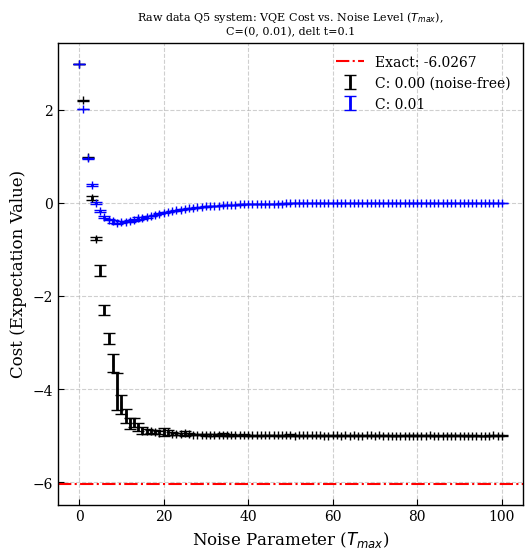

In [14]:
# Extracting components
target = "c0.089"
vqe_means_c0_01 = data_records[target]["processed"]["vqe_means"]
vqe_stds_c0_01 = data_records[target]["processed"]["vqe_stds"]
noise_levels_c0_01 = data_records[target]["processed"]["t_max"]
# Create a single clear plot
plt.figure(figsize=(6, 6))
plt.errorbar(noise_levels_c0, vqe_means_c0, yerr=vqe_stds_c0, fmt='|', color='black', 
             ecolor='black', elinewidth=2, capsize=4, markersize=6, 
             label='C: 0.00 (noise-free)')
plt.errorbar(noise_levels_c0_01, vqe_means_c0_01, yerr=vqe_stds_c0_01, fmt='|', color='blue', 
             ecolor='blue', elinewidth=2, capsize=4, markersize=6, 
             label='C: 0.01')
plt.axhline(y=EXACT_SOLUTION, color='red', linestyle='-.', label=f'Exact: {EXACT_SOLUTION:.4f}')
# Aesthetic improvements
plt.title("Raw data Q5 system: VQE Cost vs. Noise Level ($T_{max}$),\nC=(0, 0.01), delt t=0.1", fontsize=8)
plt.xlabel("Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Save the plot (if in a script) or show (if in a notebook)
# plt.savefig('raw_data_trend.png')
plt.show()

#### $\gamma$ from large $T_{max} = [50, 100]$

$$f_{\text{noisy}}(t) = B \cdot e^{-\gamma t}, \quad t \in [50, 100]$$

In [ ]:
# =========================
# Data selection (large-t window)
# =========================
mask = 51
rec = data_records["c0.01"]

t = rec["processed"]["t_max"][-mask:]
y = rec["processed"]["vqe_means"][-mask:]
sigma = rec["processed"]["vqe_stds"][-mask:]

# =========================
# Initial guesses and bounds
# Model: f(t) = B * exp(-gamma * t)
# Parameter order: [gamma, B]
# =========================
B_guess = BEST_A0_FROM_C0 + ZNE_c0_best
p0 = [
    0.05,      # gamma: slow decay at large-t
    B_guess,      # B: first point in large-t window
]

bounds = (
    [1e-6, -np.inf],   # gamma > 0, B free
    [1.0,   np.inf],   # gamma not too large (stiff), B free
)

# =========================
# Call the fitter
# =========================
result_fit_gamma_largeT = fit_gamma_largeT(
    t=t,
    y=y,
    sigma=sigma,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
    verbose=2,
)

# =========================
# Extract results
# =========================
popt = result_fit_gamma_largeT["output"]["popt"]
pcov = result_fit_gamma_largeT["output"]["pcov"]

gamma_fit, B_fit = popt

GAMMA_FROM_LARGE_T = gamma_fit
B_FROM_LARGE_T     = B_fit

# =========================
# Clean summary table
# =========================
print(f"\nLarge-T Exponential Fit: f(t) = B · exp(−γ t) with T = {t}\n")
print(f"{'param':>6} | {'initial':>12} | {'fitted':>12}")
print("-" * 36)
print(f"{'gamma':>6} | {p0[0]:12.4e} | {gamma_fit:12.4e}")
print(f"{'B':>6} | {p0[1]:12.4e} | {B_fit:12.4e}")

#### $(ZNE, A, T_0)$ from small $T_{max}=[0, 5]$

$$f_{\text{noisy}}(t) = ZNE + \frac{A}{1 + \left( \frac{t}{T_0} \right)^n} \text{ where} \quad t \in [0, 5]$$

In [ ]:
# =========================
# Data selection (large-t window)
# =========================
mask = 6
rec = data_records["c0.01"]

t = rec["processed"]["t_max"][:mask]
y = rec["processed"]["vqe_means"][:mask]
sigma = rec["processed"]["vqe_stds"][:mask]

# Initial guess and bounds
p0 = [
    ZNE_GUESS_NOISELESS, # ZNE from noise less c=0
    A0_GUESS_NOISELESS,     # A from noiseless c=0
    T0_GUESS_NOISELESS,     # T0 from noiseless c=0
]

bounds = (
    [-10.0,   0.0,  0], # lower [ ZNE, A, T0 ]
    [ 0., 200.0, 10],   # upper [ ZNE, A, T0 ]
)

result_fit_in_smallT = fit_smallT_ZNE(
    t=t,
    y=y,
    sigma=sigma,
    n=BEST_n_FROM_C0,          # fixed exponent BEST_n=2
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
    verbose=2,
)

# =====================================================
# Clean parameter summary (initial vs fitted)
# =====================================================

popt = result_fit_in_smallT["output"]["popt"]
pcov = result_fit_in_smallT["output"]["pcov"]

ZNE_fit, A_fit, T0_fit = popt

ZNE_FROM_NOISY_SMALL_T = ZNE_fit
A_FROM_NOISY_SMALL_T   = A_fit
T0_FROM_NOISY_SMALL_T  = T0_fit

print(f"\nSmall-T Hill Fit:  f(t) = ZNE + A / (1 + (t/T0)^n) with n=2, T = {t}\n")
print(f"{'param':>6} | {'initial':>12} | {'fitted':>12}")
print("-" * 36)
print(f"{'ZNE':>6} | {p0[0]:12.4f} | {ZNE_fit:12.4f}")
print(f"{'A':>6} | {p0[1]:12.4f} | {A_fit:12.4f}")
print(f"{'T0':>6} | {p0[2]:12.4f} | {T0_fit:12.4f}")


---

In [ ]:
print("All fitted parameters:")
print("****************************")
print(f"GAMMA_FROM_LARGE_T = {GAMMA_FROM_LARGE_T}")
print(f"B_FROM_LARGE_T = {B_FROM_LARGE_T}")
print(f"ZNE_FROM_NOISY_SMALL_T = {ZNE_FROM_NOISY_SMALL_T}")
print(f"A_FROM_NOISY_SMALL_T = {A_FROM_NOISY_SMALL_T}")
print(f"T0_FROM_NOISY_SMALL_T = {T0_FROM_NOISY_SMALL_T}")
print("****************************")   
print("End of fitted parameters.")

---

$$f_{\text{noisy}}(t) = e^{-\gamma t^q} \left[ \text{ZNE} + \frac{A}{1 + \left( \frac{t}{T_0} \right)^n} \right], \quad q=0.7 \text{ for } C=0.01$$

In [ ]:
F_NOISY_EQ = rf"$f(t) = e^{{-\gamma t^q}} [\mathrm{{ZNE}} + \frac{{A}}{{1 + (t/T_0)^n}}]$" + f"\n$n={BEST_n_FROM_C0}, q=0.7$"

#### Whole system fitting in $T_{max}=[0, 50]$

In [ ]:
# --- Configuration & Parameters ---
mask_idx = 51
target_key = "c0.01"
n_exponent = BEST_n_FROM_C0
q=0.7
# Initial guesses and bounds [gamma, ZNE, A, T0]
p0 = [
    GAMMA_FROM_LARGE_T,
    ZNE_FROM_NOISY_SMALL_T,
    A_FROM_NOISY_SMALL_T,
    T0_FROM_NOISY_SMALL_T
]
bounds = (
    [1e-6, -10.0, 0.0, 0],
    [1, 0., 200.0, 10]
)

# --- Data Extraction ---
rec = data_records[target_key]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Global Fit ---
result_global = fit_f_noisy(
    t=t_data, y=y_data, sigma=sigma_data, n=n_exponent, q=q,
    p0=p0, bounds=bounds, method="trf", ftol=1e-12, xtol=1e-12, gtol=1e-12
)

popt = result_global["output"]["popt"]
pcov = result_global["output"]["pcov"]

# Calculate least square errors (standard deviation) from the covariance matrix
perr = np.sqrt(np.diag(pcov))

gamma_fit, ZNE_fit, A_fit, T0_fit = popt
gamma_err, ZNE_err, A_err, T0_err = perr

# --- Print Summary ---
print(f"\nFit Results (n={n_exponent}):")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)
params = ['gamma', 'ZNE', 'A', 'T0']
for i, name in enumerate(params):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model(t, g, z, a, t0, n=n_exponent):
    return np.exp(-g * (t**q)) * (z + a / (1.0 + (t / t0) ** n))

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model(t_grid, *popt)

plt.figure(figsize=(6, 6))

# Data points
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', label="C: 0.01")
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit results
plt.plot(t_grid, y_fit, color="blue", lw=2, label="Global fit")
plt.scatter(0, ZNE_fit, color="blue", marker="x", s=100, zorder=5, label=f"ZNE: {ZNE_fit:.4f} in T_max=[0, {mask_idx-1}]")

# Annotation & Style
# Including the error +/- in the optimum string
optimum_val_str = (
    f"Optimum (C=0.01):\n"
    f"ZNE: {ZNE_fit:.6f} ± {ZNE_err:.6f}\n"
    f"A: {A_fit:.4f} ± {A_err:.4f}\n"
    f"T0: {T0_fit:.2f} ± {T0_err:.2f}\n"
    f"γ: {gamma_fit:.4e} ± {gamma_err:.4e}"
)

eq_text = (F_NOISY_EQ)
plt.text(0.5, 0.55, eq_text, transform=plt.gca().transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=0.8))
plt.text(0.5, 0.35, optimum_val_str, transform=plt.gca().transAxes, fontsize=8, bbox=dict(facecolor='white', alpha=0.8))

plt.title("VQE Cost vs. Noise Level", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.show()

#### Whole system fitting in $T_{max}=[0, 100]$

In [ ]:
# --- Configuration & Parameters ---
mask_idx = 101
target_key = "c0.01"
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, ZNE, A, T0]
p0 = [
    GAMMA_FROM_LARGE_T,
    ZNE_FROM_NOISY_SMALL_T,
    A_FROM_NOISY_SMALL_T,
    T0_FROM_NOISY_SMALL_T
]
bounds = (
    [1e-6, -10.0, 0.0, 0],
    [1, 0., 200.0, 10]
)

# --- Data Extraction ---
rec = data_records[target_key]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Global Fit ---
result_global = fit_f_noisy(
    t=t_data, y=y_data, sigma=sigma_data, n=n_exponent, q=q,
    p0=p0, bounds=bounds, method="trf", ftol=1e-12, xtol=1e-12, gtol=1e-12
)

popt = result_global["output"]["popt"]
pcov = result_global["output"]["pcov"]

# Calculate least square errors (standard deviation) from the covariance matrix
perr = np.sqrt(np.diag(pcov))

gamma_fit, ZNE_fit, A_fit, T0_fit = popt
gamma_err, ZNE_err, A_err, T0_err = perr

# --- Print Summary ---
print(f"\nFit Results (n={n_exponent}):")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)
params = ['gamma', 'ZNE', 'A', 'T0']
for i, name in enumerate(params):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model(t, g, z, a, t0, n=n_exponent):
    return np.exp(-g * (t**q)) * (z + a / (1.0 + (t / t0) ** n))

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model(t_grid, *popt)

plt.figure(figsize=(6, 6))

# Data points
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', label="C: 0.01")
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit results
plt.plot(t_grid, y_fit, color="blue", lw=2, label="Global fit")
plt.scatter(
    0, ZNE_fit, 
    color="#000080", marker="x", s=100, zorder=5, 
    label=rf"$\text{{ZNE}}: {ZNE_fit:.4f}$ for $T_{{\max}} \in [0, {mask_idx-1}]$"
)

# Annotation & Style
# Including the error +/- in the optimum string
optimum_val_str = (
    f"Optimum:\n"
    f"ZNE: {ZNE_fit:.6f} ± {ZNE_err:.6f}\n"
    f"A: {A_fit:.4f} ± {A_err:.4f}\n"
    f"T0: {T0_fit:.2f} ± {T0_err:.2f}\n"
    f"γ: {gamma_fit:.4e} ± {gamma_err:.4e}\n\n"
    f"Bounds:\nγ ∈ [{bounds[0][0]:.1e}, {bounds[1][0]:.1e}], \nZNE ∈ [{bounds[0][1]:.1f}, {bounds[1][1]:.1f}], \nA ∈ [{bounds[0][2]:.1f}, {bounds[1][2]:.1f}], \nT0 ∈ [{bounds[0][3]:.1f}, {bounds[1][3]:.1f}]"
)

eq_text = (F_NOISY_EQ)
plt.text(0.5, 0.55, eq_text, transform=plt.gca().transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.text(0.5, 0.08, optimum_val_str, transform=plt.gca().transAxes, fontsize=9, bbox=dict(facecolor='white', alpha=0.8))

plt.title("ZNE Estimation", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.show()

---

#### Optimizing $q$ test

Fitting parameters $(\gamma, ZNE, A, T_0, q)$

$$f_{\text{noisy}}(t) = e^{-\gamma t^q} \left[ \text{ZNE} + \frac{A}{1 + \left( \frac{t}{T_0} \right)^n} \right]$$

In [ ]:
F_NOISY_EQ = rf"$f(t) = e^{{-\gamma t^q}} [\mathrm{{ZNE}} + \frac{{A}}{{1 + (t/T_0)^n}}]$" + f"\n$n={BEST_n_FROM_C0}$"

In [ ]:
# --- Configuration & Parameters ---
mask_idx = 51
target_key = "c0.01"
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, ZNE, A, T0, q]
# p0 uses your carefully crafted variables with q initialized at 1.0
p0 = [
    gamma_fit, ZNE_fit, A_fit, T0_fit,
    0.8
]

bounds = (
    [1e-6, -10.0, 0.0, 0, 0.7], # Lower
    [1.0, 0.0, 200.0, 10, 1.3]   # Upper (constrained q to +10%)
)

# --- Data Extraction ---
rec = data_records[target_key]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Global Fit ---
# Note: Using your updated function name fit_fq_noisy
result_global = fit_fq_noisy(
    t=t_data, y=y_data, sigma=sigma_data, n=n_exponent,
    p0=p0, bounds=bounds, method="trf", ftol=1e-12, xtol=1e-12, gtol=1e-12
)

popt = result_global["output"]["popt"]
pcov = result_global["output"]["pcov"]

# Calculate least square errors from covariance matrix
perr = np.sqrt(np.diag(pcov))

# Unpacking results
gamma_fit, ZNE_fit, A_fit, T0_fit, q_fit = popt
gamma_err, ZNE_err, A_err, T0_err, q_err = perr

# --- Print Summary ---
print(f"\nFit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)
params_names = ['gamma', 'ZNE', 'A', 'T0', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
# Cleaned up model to work correctly with *popt unpacking
def f_noisy_model(t, g, z, a, t0, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (z + a / (1.0 + (t / t0) ** n))

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
# This now correctly passes (t_grid, gamma, ZNE, A, T0, q_fit)
y_fit = f_noisy_model(t_grid, *popt)

plt.figure(figsize=(6, 6))

# Data points
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label="C: 0.01")
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit results
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"Global fit (q={q_fit:.3f})")
plt.scatter(0, ZNE_fit, color="blue", marker="x", s=100, zorder=5, label=f"ZNE: {ZNE_fit:.4f} in T_max=[0, {mask_idx-1}]")

# Annotation & Style
optimum_val_str = (
    f"Optimum (C=0.01):\n"
    f"ZNE: {ZNE_fit:.6f} ± {ZNE_err:.6f}\n"
    f"A: {A_fit:.4f} ± {A_err:.4f}\n"
    f"T0: {T0_fit:.2f} ± {T0_err:.2f}\n"
    f"γ: {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q: {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\nγ ∈ [{bounds[0][0]:.1e}, {bounds[1][0]:.1e}], \nZNE ∈ [{bounds[0][1]:.1f}, {bounds[1][1]:.1f}], \nA ∈ [{bounds[0][2]:.1f}, {bounds[1][2]:.1f}], \nT0 ∈ [{bounds[0][3]:.1f}, {bounds[1][3]:.1f}], \nq ∈ [{bounds[0][4]:.1f}, {bounds[1][4]:.1f}]"
)

# Placed boxes in a clear area (middle-right)
plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(0.5, 0.07, optimum_val_str, transform=plt.gca().transAxes, fontsize=9, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))

plt.title("Fitting $(ZNE, A, T_0, \gamma, q)$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()

---

#### Whole system re-fitting in $T_{max}=[10, 40]$ using optimums in $T_{max}=[0, 100]$


In [ ]:
# =====================================================
# 1. Configuration & Parameters
# =====================================================
mask_idx = 41              # Upper bound index
start_idx = 10             # Lower bound index
target_key = "c0.01"
n_exponent = BEST_n_FROM_C0

# Initial guesses: Using your previous fit results as the starting point
# [gamma, ZNE, A, T0]
p0 = [GAMMA_FROM_LARGE_T, ZNE_FROM_NOISY_SMALL_T, A_FROM_NOISY_SMALL_T, T0_FROM_NOISY_SMALL_T]
p0_from_entire_range = [gamma_fit, ZNE_fit, A_fit, T0_fit]
bounds = ([1e-6, -10.0, 0.0, 0], [1, 0., 200.0, 10])

# =====================================================
# 2. Data Extraction (Slicing the window)
# =====================================================
rec = data_records[target_key]
t_data = rec["processed"]["t_max"][start_idx:mask_idx]
y_data = rec["processed"]["vqe_means"][start_idx:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][start_idx:mask_idx]

# =====================================================
# 3. Execution: Global Fit
# =====================================================
result_global = fit_f_noisy(
    t=t_data, 
    y=y_data, 
    sigma=sigma_data, 
    n=n_exponent,
    p0=p0_from_entire_range, 
    bounds=bounds, 
    method="trf", 
    ftol=1e-12, 
    xtol=1e-12, 
    gtol=1e-12,
    verbose=0
)

popt = result_global["output"]["popt"]
pcov = result_global["output"]["pcov"]
gamma_fit, ZNE_fit, A_fit, T0_fit = popt

# --- Print Summary Table ---
print(f"\nFit Results for Window [{start_idx}:{mask_idx}] (n={n_exponent}):")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Rel. Error'}")
print("-" * 62)
params_names = ['gamma', 'ZNE', 'A', 'T0']
for i, name in enumerate(params_names):
    rel_err = np.sqrt(pcov[i,i]) / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0_from_entire_range[i]:12.4e} | {popt[i]:12.4e} | {rel_err:.2e}")

# =====================================================
# 4. Visualization
# =====================================================
def f_noisy_model(t, g, z, a, t0, n=n_exponent):
    return np.exp(-g * t) * (z + a / (1.0 + (t / t0) ** n))

# Generate smooth curve for plotting
t_grid = np.linspace(0, max(noise_levels_c0_01), 400)
y_fit_curve = f_noisy_model(t_grid, *popt)

plt.figure(figsize=(6, 6))

# A. Highlight the "Masked" Data Range
t_min_window = rec["processed"]["t_max"][start_idx]
t_max_window = rec["processed"]["t_max"][mask_idx-1]
plt.axvspan(t_min_window, t_max_window, color='gray', alpha=0.1, label=f'Fit Window (idx {start_idx}-{mask_idx})')

# B. Plot all data points
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.4, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label="C: 0.01 (all data)")

# C. Highlight specific points used in this fit
plt.scatter(t_data, y_data, facecolors='none', edgecolors='red', s=50, linewidth=1, label='Points used in final ZNE fit')

# D. Plot exact solution and ZNE result
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", alpha=0.7, label=f"Exact: {EXACT_SOLUTION:.4f}")
plt.plot(t_grid, y_fit_curve, color="blue", lw=2, label="Global fit curve")
plt.scatter(0, ZNE_fit, color="blue", marker="x", s=150, zorder=5, label=f"ZNE: {ZNE_fit:.4f}")

# E. Annotation & Styling
eq_text = (F_NOISY_EQ)
plt.text(0.5, 0.1, eq_text, transform=plt.gca().transAxes, fontsize=11, 
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='lightgray'))
plt.title(f"re-fitting using optimums in T_max =[0, 100] ", fontsize=12)
plt.xlabel(f"Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.4)
plt.legend(loc='upper right', fontsize=9, framealpha=1)

plt.tight_layout()
plt.show()

In [ ]:
lsf_fit_gamma_largeT = {
    "name": "fit_gamma_largeT",
    "model": "exp(-gamma t) * B",
    "result": result_fit_gamma_largeT,
}

lsf_fit_in_smallT = {
    "name": "fit_in_smallT",
    "model": "ZNE + A / (1 + (t/T0)^n)",
    "result": result_fit_in_smallT,
}

lsf_fit_global = {
    "name": "fit_global",
    "model": "exp(-gamma t) * (ZNE + A / (1 + (t/T0)^n))",
    "result": result_global,
}
gamma_noisy_opt = lsf_fit_global["result"]["output"]["popt"][0]
ZNE_noisy_opt = lsf_fit_global["result"]["output"]["popt"][1]
A_noisy_opt = lsf_fit_global["result"]["output"]["popt"][2]
T0_noisy_opt = lsf_fit_global["result"]["output"]["popt"][3]

print("\nFinal optimized parameters from global fit:")
print(f"  gamma: {gamma_noisy_opt:.6e}")
print(f"  ZNE  : {ZNE_noisy_opt:.6f}")
print(f"  A    : {A_noisy_opt:.6f}")
print(f"  T0   : {T0_noisy_opt:.6f}")

---

### Fitting $\gamma, q$ with fixed parameters (ZNE, A, T0, n)

$$f_{\text{noisy}}(t) = e^{-\gamma t^q} \left[ \text{ZNE} + \frac{A}{1 + \left( \frac{t}{T_0} \right)^n} \right]$$

In [ ]:
# --- Configuration & Parameters ---
mask_idx = 51

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0


# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.6],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
TARGET_C = "c0.01"
C_VAL_str = "C: 0.01"
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}"
)

plt.text(
    0.45, 0.50, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


In [ ]:
# --- Configuration & Parameters ---
mask_idx = 101

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0


# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.6],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
TARGET_C = "c0.01"
C_VAL_str = "C: 0.01"
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}"
)

plt.text(
    0.45, 0.50, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


In [ ]:
# --- Configuration & Parameters ---
mask_idx = 31

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0


# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
TARGET_C = "c0.01"
C_VAL_str = "C: 0.01"
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n"
    f"q ∈ [{bounds[0][1]:.2f}, {bounds[1][1]:.2f}]"
)

plt.text(
    0.45, 0.30, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


In [ ]:
# --- Configuration & Parameters ---
mask_idx = 51

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0


# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
TARGET_C = "c0.01"
C_VAL_str = "C: 0.01"
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n"
    f"q ∈ [{bounds[0][1]:.2f}, {bounds[1][1]:.2f}]"
)

plt.text(
    0.45, 0.30, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


In [ ]:
# --- Configuration & Parameters ---
mask_idx = 101

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0


# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
TARGET_C = "c0.01"
C_VAL_str = "C: 0.01"
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

# --- Visualization ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=0.3, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n"
    f"q ∈ [{bounds[0][1]:.2f}, {bounds[1][1]:.2f}]"
)

plt.text(
    0.45, 0.30, optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


Dtailed pottting

In [ ]:
# --- Configuration & Parameters ---
mask_idx = 31

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.07,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


In [ ]:
# --- Configuration & Parameters ---
mask_idx = 51

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.07,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


In [ ]:
# --- Configuration & Parameters ---
mask_idx = 101

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
sigma_data = rec["processed"]["vqe_stds"][:mask_idx]

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.07,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


setting std = [1] and reduced xi

In [ ]:
# --- Configuration & Parameters ---
mask_idx = 31

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
#sigma_data = rec["processed"]["vqe_stds"][:mask_idx]
sigma_data = np.ones_like(y_data) # std = 1

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.07,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


In [ ]:
# --- Configuration & Parameters ---
mask_idx = 51

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
#sigma_data = rec["processed"]["vqe_stds"][:mask_idx]
sigma_data = np.ones_like(y_data) # std = 1

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.07,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


In [ ]:
# --- Configuration & Parameters ---
mask_idx = 101

# Fixed constants (naming preserved)
n_exponent = BEST_n_FROM_C0

# Initial guesses and bounds [gamma, q]
p0 = [
    GAMMA_FROM_LARGE_T,  # reuse previous gamma estimate
    0.8
]

bounds = (
    [1e-6, 0.5],   # Lower bounds [gamma, q]
    [1.0,  1.3],   # Upper bounds
)

# --- Data Extraction ---
rec = data_records[TARGET_C]
t_data = rec["processed"]["t_max"][:mask_idx]
y_data = rec["processed"]["vqe_means"][:mask_idx]
#sigma_data = rec["processed"]["vqe_stds"][:mask_idx]
sigma_data = np.ones_like(y_data) # std = 1

# --- Execution: Gamma–q Fit (constants fixed) ---
result_gq = fit_fq_noisy_gamma_q_only(
    t=t_data,
    y=y_data,
    sigma=sigma_data,
    ZNE=ZNE_c0_best,
    A=BEST_A0_FROM_C0,
    T0=BEST_T0_FROM_C0,
    n=n_exponent,
    p0=p0,
    bounds=bounds,
    method="trf",
    ftol=1e-12,
    xtol=1e-12,
    gtol=1e-12,
)

popt = result_gq["output"]["popt"]
pcov = result_gq["output"]["pcov"]

# Errors
perr = np.sqrt(np.diag(pcov))

# Unpack
gamma_fit, q_fit = popt
gamma_err, q_err = perr

# --- Reduced Chi-square calculation ---
def f_noisy_model_fixed(t, g, q_val, n=n_exponent):
    return np.exp(-g * (t**q_val)) * (
        ZNE_c0_best + BEST_A0_FROM_C0 / (1.0 + (t / BEST_T0_FROM_C0) ** n)
    )

y_model_data = f_noisy_model_fixed(t_data, gamma_fit, q_fit)

chi2 = np.sum(((y_data - y_model_data) / sigma_data) ** 2)
N = len(t_data)
p = 2  # gamma, q
dof = N - p
chi2_red = chi2 / dof

# --- Print Summary ---
print(f"\nGamma–q Fit Results (n={n_exponent}), T_max={t_data}")
print(f"{'Param':>6} | {'Initial':>12} | {'Fitted':>12} | {'Error':>12} | {'Rel. Error'}")
print("-" * 75)

params_names = ['gamma', 'q']
for i, name in enumerate(params_names):
    rel_err = perr[i] / abs(popt[i]) if popt[i] != 0 else 0
    print(f"{name:>6} | {p0[i]:12.4e} | {popt[i]:12.4e} | {perr[i]:12.4e} | {rel_err:.2e}")

print(f"\nReduced chi-square = {chi2_red:.4f} (dof = {dof})")

# --- Visualization ---
t_grid = np.linspace(min(noise_levels_c0_01), max(noise_levels_c0_01), 400)
y_fit = f_noisy_model_fixed(t_grid, gamma_fit, q_fit)

plt.figure(figsize=(6, 6))

# Data
plt.plot(noise_levels_c0, vqe_means_c0, 'k.', alpha=1, label="C: 0.00 (noise-free)")
plt.plot(noise_levels_c0_01, vqe_means_c0_01, 'm.', markersize=4, label=C_VAL_str)
plt.axhline(EXACT_SOLUTION, color="red", linestyle="-.", label=f"Exact: {EXACT_SOLUTION:.4f}")

# Fit
plt.plot(t_grid, y_fit, color="blue", lw=2, label=f"γ, q fit in T_max=[0, {mask_idx-1}]")
plt.scatter(
    0, ZNE_c0_best,
    color="blue", marker="x", s=100, zorder=5,
    label=f"ZNE (fixed): {ZNE_c0_best:.4f}"
)

# Annotation (now includes reduced chi-square)
optimum_val_str = (
    f"Fixed from C0:\n"
    f"ZNE = {ZNE_c0_best:.6f}\n"
    f"A   = {BEST_A0_FROM_C0:.4f}\n"
    f"T0  = {BEST_T0_FROM_C0:.2f}\n"
    f"n   = {n_exponent}\n\n"
    f"Optimums:\n"
    f"γ = {gamma_fit:.4e} ± {gamma_err:.4e}\n"
    f"q = {q_fit:.4f} ± {q_err:.4f}\n\n"
    f"Bounds:\n"
    f"γ ∈ [{bounds[0][0]:.2e}, {bounds[1][0]:.2e}]\n\n"
    f"Reduced χ² = {chi2_red:.2e}\n"
    f"dof = {dof}"
)

plt.text(0.45, 0.60, F_NOISY_EQ, transform=plt.gca().transAxes, fontsize=10, 
         bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray'))
plt.text(
    0.45, 0.07,
    optimum_val_str,
    transform=plt.gca().transAxes,
    fontsize=9,
    bbox=dict(facecolor='white', alpha=0.85, edgecolor='lightgray')
)

plt.title("Fitting $(\gamma, q)$ with $(ZNE, A, T_0) fixed$", fontsize=10)
plt.xlabel("Noise Parameter ($T_{max}$)")
plt.ylabel("Cost")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=8, loc='upper right')

plt.show()


---

> Could you calculate:
> $$R(T_{\max}, C) := -\log \left( \frac{E_{\text{noisy}}(T_{\max}, C)}{E_{\text{ideal}}(T_{\max})} \right)$$
> 
> If the ratio of these values for different noise levels $C_1$ and $C_2$ is constant:
> $$\frac{R(T, C_1)}{R(T, C_2)} \approx \text{const}(C_1, C_2)$$
> 
> That is, if $\frac{R(T, C_1)}{R(T, C_2)}$ is almost constant with $T$, then we are seeing something physical.

In [ ]:
vqe_means_by_c = {}
vqe_stds_by_c = {}
t_vals_by_c = {}

data_root = Path("data")

for c_dir in sorted(data_root.glob("c*")):
    # skip non-directories just in case
    if not c_dir.is_dir():
        continue

    # extract numeric C value: "c0.022" -> 0.022
    c = float(c_dir.name[1:])

    record = data_records[c_dir.name]["processed"]

    vqe_means_by_c[c] = record["vqe_means"]
    vqe_stds_by_c[c] = record["vqe_stds"]
    t_vals_by_c[c] = record["t_max"]


Checking

In [ ]:
check_c_temp = "c0.2"
data_temp_cost = data_records[check_c_temp]["processed"]["vqe_means"]
data_temp_t_max = data_records[check_c_temp]["processed"]["t_max"]

print(f"Noise Level: {check_c_temp} | Points: {len(data_temp_cost)}")
print(f"{'T_max':<10} | {'VQE Mean (Cost)':<20}")
print("-" * 35)

# Use a loop to print row by row
for t, cost in zip(data_temp_t_max, data_temp_cost):
    print(f"{t:<10.2f} | {cost:<20.8f}")

# Cleanup
del check_c_temp, data_temp_cost, data_temp_t_max

In [ ]:
# --- Backward compatibility aliases ---

vqe_means_c0    = vqe_means_by_c[0]
vqe_stds_c0     = vqe_stds_by_c[0]
noise_levels_c0 = t_vals_by_c[0]

vqe_means_c0_01    = vqe_means_by_c[0.01]
vqe_stds_c0_01     = vqe_stds_by_c[0.01]
noise_levels_c0_01 = t_vals_by_c[0.01]

vqe_means_c0_05    = vqe_means_by_c[0.05]
vqe_stds_c0_05     = vqe_stds_by_c[0.05]
noise_levels_c0_05 = t_vals_by_c[0.05]

vqe_means_c0_1     = vqe_means_by_c[0.1]
vqe_stds_c0_1      = vqe_stds_by_c[0.1]
noise_levels_c0_1  = t_vals_by_c[0.1]

vqe_means_c0_2     = vqe_means_by_c[0.2]
vqe_stds_c0_2      = vqe_stds_by_c[0.2]
noise_levels_c0_2  = t_vals_by_c[0.2]

vqe_means_c0_5     = vqe_means_by_c[0.5]
vqe_stds_c0_5      = vqe_stds_by_c[0.5]
noise_levels_c0_5  = t_vals_by_c[0.5]


In [ ]:
# --- Containers ---
R_ratio_vals = []
E_noisy_c_1 = []
E_noisy_c_2 = []

# --- Main loop (no physics changed) ---
for E_ideal, E_c1, E_c2 in zip(
        vqe_means_by_c[0],
        vqe_means_by_c[0.01],
        vqe_means_by_c[0.05]
    ):
    R1 = -np.log(E_c1 / E_ideal)
    R2 = -np.log(E_c2 / E_ideal)

    R_ratio_vals.append(R1 / R2)
    E_noisy_c_1.append(np.log((10+E_c1)))
    E_noisy_c_2.append(np.log((10+E_c2)))

# --- Convert to arrays ---
R_ratio_vals = np.array(R_ratio_vals)
E_noisy_c_1 = np.array(E_noisy_c_1)
E_noisy_c_2 = np.array(E_noisy_c_2)

# --- Fix length mismatch (CRITICAL) ---
N = len(R_ratio_vals)
T_plot = noise_levels_c0[:N]

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(6, 6))

# Left axis: R ratio
ax1.plot(
    T_plot,
    R_ratio_vals,
    '*-',
    color='black',
    markersize=3,
    label=r"$R(T,C_1)/R(T,C_2)$"
)
ax1.set_xlabel("$T_{max}$")
ax1.set_ylabel("R(T,C1) / R(T,C2)", color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True)

# Right axis: log energies
ax2 = ax1.twinx()
ax2.plot(
    T_plot,
    E_noisy_c_1[:N],
    '*--',
    color='blue',
    markersize=4,
    label=r"$\log |E_{\mathrm{noisy}}(C=0.01)|$"
)

ax2.plot(
    T_plot,
    E_noisy_c_2[:N],
    '*--',
    color='red',
    markersize=4,
    label=r"$\log |E_{\mathrm{noisy}}(C=0.05)|$"
)

ax2.set_ylabel(r"$\log (E_{\mathrm{noisy} + 10)}$", color='black')
ax2.tick_params(axis='y', labelcolor='black')

# --- Legends (both axes) ---
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc="best")

plt.title("R-ratio test")
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(6, 6))

# --- Noise-free ---
plt.errorbar(
    noise_levels_c0,
    vqe_means_c0,
    yerr=vqe_stds_c0,
    fmt='|',
    color='black',
    ecolor='#bdc3c7',
    elinewidth=2,
    capsize=4,
    markersize=6,
    label='C: 0.00 (noise-free)'
)

# --- C = 0.01 ---
plt.errorbar(
    noise_levels_c0_01,
    vqe_means_c0_01,
    yerr=vqe_stds_c0_01,
    fmt='|',
    color='magenta',
    ecolor='#bdc3c7',
    elinewidth=2,
    capsize=4,
    markersize=6,
    label='C: 0.01'
)

# --- C = 0.05 ---
plt.errorbar(
    noise_levels_c0_05,
    vqe_means_c0_05,
    yerr=vqe_stds_c0_05,
    fmt='|',
    color='blue',
    ecolor='#bdc3c7',
    elinewidth=2,
    capsize=4,
    markersize=6,
    label='C: 0.05'
)

# --- C = 0.1 ---
plt.errorbar(
    noise_levels_c0_1,
    vqe_means_c0_1,
    yerr=vqe_stds_c0_1,
    fmt='|',
    color='green',
    ecolor='#bdc3c7',
    elinewidth=2,
    capsize=4,
    markersize=6,
    label='C: 0.1'
)

# --- C = 0.2 ---
plt.errorbar(
    noise_levels_c0_2,
    vqe_means_c0_2,
    yerr=vqe_stds_c0_2,
    fmt='|',
    color='orange',
    ecolor='#bdc3c7',
    elinewidth=2,
    capsize=4,
    markersize=6,
    label='C: 0.2'
)


# --- Exact solution line ---
plt.axhline(
    y=EXACT_SOLUTION,
    color='red',
    linestyle='-.',
    label=f'Exact: {EXACT_SOLUTION:.4f}'
)

# --- Aesthetics ---
plt.title(
    "Raw data Q5 system: VQE Cost vs. Noise Level ($T_{max}$)\n"
    "C=(0, 0.01, 0.05, 0.1, 0.2, 0.5), Δt=0.1",
    fontsize=8
)
plt.xlabel("Noise Parameter ($T_{max}$)", fontsize=12)
plt.ylabel("Cost (Expectation Value)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# Extract T
T = np.array(data_records["c0.01"]["processed"]["t_max"])

# Means
E_c001 = np.array(data_records["c0.01"]["processed"]["vqe_means"])
E_c005 = np.array(data_records["c0.05"]["processed"]["vqe_means"])
E_c01  = np.array(data_records["c0.1"]["processed"]["vqe_means"])
E_c02  = np.array(data_records["c0.2"]["processed"]["vqe_means"])

# Standard deviations
std_c001 = np.array(data_records["c0.01"]["processed"]["vqe_stds"])
std_c005 = np.array(data_records["c0.05"]["processed"]["vqe_stds"])
std_c01  = np.array(data_records["c0.1"]["processed"]["vqe_stds"])
std_c02  = np.array(data_records["c0.2"]["processed"]["vqe_stds"])

def print_delta_with_std(E1, E2, std1, label):
    print("\n==============================")
    print(label)
    print("==============================")
    for i in range(len(T)):
        delta_E = E1[i] - E2[i]
        print(
            f"T={T[i]:.4f} | "
            f"ΔE={delta_E:.6e} | "
            f"σ(C1)={std1[i]:.6e}"
        )

# Comparisons (C1 − C2, and σ of C1)
print_delta_with_std(E_c001, E_c005, std_c001, "C=0.01 − C=0.05")
print_delta_with_std(E_c005, E_c01,  std_c005, "C=0.05 − C=0.1")
print_delta_with_std(E_c01,  E_c02,  std_c01,  "C=0.1 − C=0.2")


In [ ]:
# --- Extract data ---
T = np.array(data_records["c0.01"]["processed"]["t_max"])

E_c001 = np.array(data_records["c0.01"]["processed"]["vqe_means"])
E_c005 = np.array(data_records["c0.05"]["processed"]["vqe_means"])
std_c001 = np.array(data_records["c0.01"]["processed"]["vqe_stds"])
std_c005 = np.array(data_records["c0.05"]["processed"]["vqe_stds"])
std_c0 = np.array(data_records["c0"]["processed"]["vqe_stds"])
T_0 = np.array(data_records["c0"]["processed"]["t_max"])
# --- Compute Delta E ---
delta_E = E_c001 - E_c005

# --- Ensure same length ---
N = min(len(T), len(delta_E), len(std_c001))
T_plot = T[:N]
delta_E = delta_E[:N]
std_c001 = std_c001[:N]

# --- Plot ---
plt.figure(figsize=(6, 5))

plt.plot(
    T_plot,
    delta_E,
    'o-',
    color='black',
    markersize=2,
    label=r'$\Delta E = E(T,0.01) - E(T,0.05)$'
)

plt.plot(
    T_plot,
    std_c001,
    's--',
    color='blue',
    markersize=2,
    label=r'$\sigma(E(T,0.01))$'
)
plt.plot(
    T_plot,
    std_c005,
    's--',
    color='red',
    markersize=2,
    label=r'$\sigma(E(T,0.05))$'
)
plt.plot(
    T_0,
    std_c0,
    's--',
    color='cyan',
    markersize=2,
    label=r'$\sigma(E(T,0))$'
)

plt.xlabel(r"$T_{\max}$")
plt.ylabel("Energy scale")
plt.title("Comparison: ΔE vs STDs for C=0.01")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


---

Polynomial fitting of 
$R(T,C)=F0(T) + C・F1(T)+ C^2 ・F2(T)+C^3・F3(T)$


In [ ]:
# =========================
# User controls
# =========================
mask_start = 3
mask_end   = 50
poly_degree = 3

C_values = np.array([0.01, 0.05, 0.1, 0.2])

# =========================
# Apply masks
# =========================
E_c_raw = [
    vqe_means_c0_01[mask_start:mask_end],
    vqe_means_c0_05[mask_start:mask_end],
    vqe_means_c0_1[mask_start:mask_end],
    vqe_means_c0_2[mask_start:mask_end]
]
E_ideal = vqe_means_c0
E_ideal_cut = E_ideal[mask_start:mask_end]
T_values = noise_levels_c0_01[mask_start:mask_end]

E_c = np.array(E_c_raw)

# =========================
# Compute R(T,C)
# =========================
R = -np.log(np.abs(E_c / E_ideal_cut))

# =========================
# Polynomial fit in C
# =========================
n_T = len(T_values)
coeffs_T = np.zeros((n_T, poly_degree + 1))

for i in range(n_T):
    y = R[:, i]
    coeffs = np.polyfit(C_values, y, poly_degree)
    coeffs_T[i] = coeffs[::-1]   # [F0, F1, F2, ...]

# =========================
# Print results
# =========================
header = "T"
for k in range(poly_degree + 1):
    header += f"    F{k}(T)"
print(header)

for i, T in enumerate(T_values):
    row = f"{T:.6f}"
    for k in range(poly_degree + 1):
        row += f"    {coeffs_T[i, k]: .6e}"
    print(row)


>Could you changing the degree and see how the remaining square error changes depending on degree.

In [ ]:
# =========================
# User controls
# =========================
mask_start = 3
mask_end   = 50
max_degree = 3

C_values = np.array([0.01, 0.05, 0.1, 0.2])

# =========================
# Apply masks
# =========================
E_c_raw = [
    vqe_means_c0_01[mask_start:mask_end],
    vqe_means_c0_05[mask_start:mask_end],
    vqe_means_c0_1[mask_start:mask_end],
    vqe_means_c0_2[mask_start:mask_end]
]

E_ideal_cut = vqe_means_c0[mask_start:mask_end]

E_c = np.array(E_c_raw)  # shape (nC, nT)

# =========================
# Compute R(T,C)
# =========================
R = -np.log(np.abs(E_c / E_ideal_cut))

# =========================
# Degree scan
# =========================
print("Polynomial degree vs residual error")
print("-----------------------------------")

for deg in range(1, max_degree + 1):
    rss_total = 0.0

    for t_idx in range(R.shape[1]):
        y = R[:, t_idx]

        coeffs = np.polyfit(C_values, y, deg)
        y_fit = np.polyval(coeffs, C_values)

        residuals = y - y_fit
        rss_total += np.sum(residuals**2)

    print(f"Degree {deg}: RSS = {rss_total:.6e}")


In [ ]:
# =========================
# User choice
# =========================
poly_degree = 3
t_index = 3   # choose which T to visualize

# =========================
# Data at selected T
# =========================
y = R[:, t_index]          # R vs C at fixed T
C_vals = C_values

# Polynomial fit
coeffs = np.polyfit(C_vals, y, poly_degree)

# Smooth curve for plotting
C_smooth = np.linspace(min(C_vals), max(C_vals), 200)
y_fit = np.polyval(coeffs, C_smooth)

# =========================
# Plot
# =========================
plt.figure()
plt.scatter(C_vals, y)
plt.plot(C_smooth, y_fit)

plt.xlabel("C")
plt.ylabel("R(T, C)")
plt.title(f"Polynomial fit (degree={poly_degree}) at T index {t_index}")
plt.show()


---

Richardson ZNE

In [ ]:
# 1. Apply the mask: T between 3 and 20
# (Assuming vqe_means_c0_01 and noise_levels_c0_01 are defined in your environment)
noise_arr = np.array(noise_levels_c0_01)
means_arr = np.array(vqe_means_c0_01)

mask = (noise_arr >= 50) & (noise_arr <= 70)
masked_T = noise_arr[mask]
masked_means = means_arr[mask]

window_size = 3
print(f"C = 0.01 | T range: {masked_T[0]:.2f} to {masked_T[-1]:.2f} | Total points: {len(masked_T)}\n")
print(f"{'Window':<10} | {'Input T [points used]':<45} | {'ZNE Value':<12}")
print("-" * 85)

# 3. Slide the window and apply ZNE
results = []

for i in range(len(masked_T) - window_size + 1):
    # Extract current window
    current_T = masked_T[i : i + window_size]
    current_means = masked_means[i : i + window_size]
    
    try:
        # Perform ZNE using your logic from riczne.py
        # Note: RichardsonZne sorts the noise internally
        res = RichardsonZne(list(current_means), list(current_T))
        zne_val = res['extrapolated_val']
        
        # Formatting for display
        t_list_str = str([round(t, 2) for t in current_T])
        window_label = f"{i} to {i + window_size - 1}"
       
        print(f"{window_label:<10} | {t_list_str:<45} | {zne_val:<12.6f}")
        
        results.append(res)
        
    except Exception as e:
        print(f"Error in window {i}: {e}")

In [ ]:
# 1. Apply the mask: T between 3 and 20
# (Assuming vqe_means_c0_01 and noise_levels_c0_01 are defined in your environment)
noise_arr = np.array(noise_levels_c0_05)
means_arr = np.array(vqe_means_c0_05)

mask = (noise_arr >= 3) & (noise_arr <= 20)
masked_T = noise_arr[mask]
masked_means = means_arr[mask]

window_size = 2
print(f"C = 0.05 | T range: {masked_T[0]:.2f} to {masked_T[-1]:.2f} | Total points: {len(masked_T)}\n")
print(f"{'Window':<10} | {'Input T [points used]':<45} | {'ZNE Value':<12}")
print("-" * 85)

# 3. Slide the window and apply ZNE
results = []

for i in range(len(masked_T) - window_size + 1):
    # Extract current window
    current_T = masked_T[i : i + window_size]
    current_means = masked_means[i : i + window_size]
    
    try:
        # Perform ZNE using your logic from riczne.py
        # Note: RichardsonZne sorts the noise internally
        res = RichardsonZne(list(current_means), list(current_T))
        zne_val = res['extrapolated_val']
        
        # Formatting for display
        t_list_str = str([round(t, 2) for t in current_T])
        window_label = f"{i} to {i + window_size - 1}"
       
        print(f"{window_label:<10} | {t_list_str:<45} | {zne_val:<12.6f}")
        
        results.append(res)
        
    except Exception as e:
        print(f"Error in window {i}: {e}")

---

Unifromly sampled
$C= [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.200]$

In [ ]:
plt.figure(figsize=(5, 5))

# Filter for the specific target values of C
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111,
               0.133, 0.156, 0.178, 0.190, 0.200, 0.210]
Cs = [c for c in target_vals if c in vqe_means_by_c]

# Use tab20 for >10 curves (high contrast, discrete)
colors = plt.cm.tab20.colors[:len(Cs)]

for c, color in zip(Cs, colors):
    label = "C: 0 (noise-free)" if np.isclose(c, 0.0) else f"C: {c:g}"
    plt.plot(
        t_vals_by_c[c],
        vqe_means_by_c[c],
        linewidth=1.6,
        alpha=1.0,
        color=color,
        label=label
    )

# Exact line (black is better than red for papers)
plt.axhline(
    y=EXACT_SOLUTION,
    linestyle='--',
    linewidth=2.0,
    color='black',
    label=f'Exact: {EXACT_SOLUTION:.3f}'
)

plt.xlabel("$T_{max}$")
plt.ylabel("VQE Cost")
plt.title("VQE Cost vs Noise Parameter for Different C", fontsize=8)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(
    loc="lower right",
    fontsize=7,
    frameon=True,
    edgecolor='black',
    facecolor='#f7f7f7',
    framealpha=1
)

plt.tight_layout()
plt.show()


In [ ]:
# --- Fixed Mapping for VQE Cost vs Tmax ---
plt.figure(figsize=(5, 5))

# Use strict matching to find the actual keys in the dictionary
target_summary = [0.0, 0.022, 0.190, 0.2, 0.210]
Cs_verified = []
for val in target_summary:
    match = [k for k in vqe_means_by_c.keys() if np.isclose(k, val, atol=1e-5)]
    if match: Cs_verified.append(match[0])

# Colors from Inferno
colors = cm.tab10.colors[:len(Cs_verified)]

for c, color in zip(Cs_verified, colors):
    # Using target_summary value for clean labels
    label = "C: 0 (noise-free)" if np.isclose(c, 0.0) else f"C: {c:g}"
    plt.plot(
        t_vals_by_c[c],
        vqe_means_by_c[c],
        linewidth=1.5,
        alpha=0.9,
        color=color,
        label=label
    )

plt.axhline(y=EXACT_SOLUTION, linestyle='--', linewidth=1.8, color='red', label=f'Exact: {EXACT_SOLUTION:.3f}')

plt.xlabel("$T_{max}$")
plt.ylabel("VQE Cost")
plt.title("VQE Cost vs Noise Parameter for Different C", fontsize=8)
plt.grid(True, linestyle='--', alpha=0.5, color='#d1d1d1') # Fixed visibility

plt.legend(loc="lower right", fontsize=7, frameon=True, edgecolor='black', facecolor='#f7f7f7', framealpha=1)
plt.tight_layout()
plt.show()

---

#### Polynomial Fitting of $R(T, C)$

Since $R(T, C=0) = 0$ for all $T$,  
the constant term must vanish in the polynomial expansion.

Therefore, we impose $F_0(T) = 0$, and write

$$
R(T, C) = C\,F_1(T) + C^2 F_2(T) + C^3 F_3(T) + C^4 F_4(T) + \cdots
$$

This enforces the physical constraint that the noise response
vanishes when $C = 0$.


In [ ]:
degrees = [1, 2, 3]

fix_T   = 3
T_start = 3
T_end   = 50

# --------------------------------------------------
# 1. Check that fix_T is inside the selected range
# --------------------------------------------------
if fix_T < T_start or fix_T > T_end:
    raise ValueError("fix_T is outside selected T range")

# --------------------------------------------------
# 2. Select energy values in T range
# --------------------------------------------------
selected_vqe_E = {}

for C, full_energy_array in vqe_means_by_c.items():
    selected_vqe_E[C] = full_energy_array[T_start:T_end + 1]

# --------------------------------------------------
# 3. Convert fix_T to local index
# --------------------------------------------------
local_T = fix_T - T_start
# --------------------------------------------------
# 4. Compute R(C, fix_T)
# --------------------------------------------------
E_ideal = selected_vqe_E[0.0][local_T]

C_values = []
R_values = []

for C, energy_array in selected_vqe_E.items():

    E_noisy = energy_array[local_T]
    ratio = E_noisy / E_ideal

    if ratio > 0:
        C_values.append(C)
        R_values.append(-np.log(ratio))


C_values = np.array(C_values)
R_values = np.array(R_values)
# --------------------------------------------------
# 5. Remove C = 0 before fitting
# --------------------------------------------------
fit_mask = C_values > 0

C_fit = C_values[fit_mask]
R_fit = R_values[fit_mask]
# --------------------------------------------------
# 6. Polynomial fitting (no constant term)
# --------------------------------------------------
fitted_coefficients = {}

for degree in degrees:

    if len(C_fit) <= degree:
        continue

    X = np.column_stack([
        C_fit**k for k in range(1, degree + 1)
    ])

    coeffs, _, _, _ = np.linalg.lstsq(X, R_fit, rcond=None)

    fitted_coefficients[degree] = coeffs
# --------------------------------------------------
# 7. Print results
# --------------------------------------------------
for degree, coeffs in fitted_coefficients.items():

    print(f"\nDegree {degree} fit at T = {fix_T}")

    for k, value in enumerate(coeffs, start=1):
        print(f"F{k}(T={fix_T}) = {value:.6e}")


Ratio sign checking for a given $T$

In [ ]:
T = 3
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.190, 0.200, 0.210]
E_ideal = vqe_means_by_c[0.0][T]
C_list = []
ratio_list = []
for c in target_vals:

    if c in vqe_means_by_c:

        E_noisy = vqe_means_by_c[c][T]
        ratio = E_noisy / E_ideal

        print(f"C = {c}, ratio = {ratio}")

        C_list.append(c)
        ratio_list.append(ratio)

C_array = np.array(C_list)
ratio_array = np.array(ratio_list)

plt.figure()
plt.scatter(C_array, ratio_array, color="black")
plt.axhline(y=0, color="red")   # horizontal zero line
plt.xlabel("C")
plt.ylabel("$E_{noisy}$ / $E_{ideal}$")
plt.title(f"Ratio vs C at T={T}")
plt.grid(True)
plt.show()


In [ ]:
T = 5
T_min = 3
T_max = 50
degrees = 3
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.190, 0.200, 0.210]

if T < T_min or T > T_max:
    raise ValueError("T is outside selected range")

E_ideal = vqe_means_by_c[0.0][T]

def compute_R(c):
    """Return R(T, c) = -log(E_noisy / E_ideal)."""

    E_noisy = vqe_means_by_c[c][T]
    ratio = E_noisy / E_ideal

    print(f"Ratio E_noise(T={T}, C={c}) / E_ideal(T={T}) = {ratio}")
    
    if ratio > 0:
        return -np.log(ratio)
    else:
        print("Log -ve val error")
        print("T =", T)
        print("C =", c)
        print("E_noisy =", E_noisy)
        print("E_ideal =", E_ideal)
        print("ratio =", ratio)
        print("-----------------------------")
        return np.nan

# ======================
# Select C values present in data
# ======================
C_list = []

for c in target_vals:
    if c in vqe_means_by_c:
        C_list.append(c)

C = np.array(C_list)

# Compute R values
R_list = []

for c in C:
    R_list.append(compute_R(c))

R = np.array(R_list)

# ======================
# Use valid data and exclude C=0
# ======================
mask = (C > 0) & np.isfinite(R)

C_fit = C[mask]
R_fit = R[mask]

# ======================
# Build design matrix (no constant term)
# ======================
X_columns = []

for k in range(1, degrees + 1):
    X_columns.append(C_fit ** k)

X = np.column_stack(X_columns)

# ======================
# Least squares solve
# ======================
F, residuals, rank, singular_values = np.linalg.lstsq(X, R_fit, rcond=None)

# ======================
# Print coefficients
# ======================
for k in range(1, degrees + 1):
    print("************************")
    print(f"F{k}(T={T}) = {F[k-1]:.6e}")

# ======================
# Plot
# ======================
plt.figure()

plt.scatter(C, R, color="black", label="Data")

C_smooth = np.linspace(0, C.max(), 200)
R_smooth = np.zeros_like(C_smooth)

for k in range(1, degrees + 1):
    R_smooth = R_smooth + F[k-1] * (C_smooth ** k)

plt.plot(C_smooth, R_smooth, color="blue",
         label=f"Degree {degrees} (no intercept)")

plt.xlabel("C")
plt.ylabel("R(T, C)")
plt.title(f"Constrained Polynomial Fit at T={T}")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# ======================
# User settings
# ======================
T = 3
T_min = 3
T_max = 50
degrees = [1, 2, 3, 4, 5]

#target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.190, 0.200, 0.210]
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089]
if T < T_min or T > T_max:
    raise ValueError("T is outside selected range")

E_ideal = vqe_means_by_c[0.0][T]

# ======================
# Compute R(T, C)
# ======================
def compute_R(c):
    E_noisy = vqe_means_by_c[c][T]
    ratio = E_noisy / E_ideal
    
    if ratio > 0:
        return -np.log(ratio)
    else:
        return np.nan

# ======================
# Collect valid C values
# ======================
C_list = [c for c in target_vals if c in vqe_means_by_c]
C = np.array(C_list)

R = np.array([compute_R(c) for c in C])

# Exclude C=0 and invalid values
mask = (C > 0) & np.isfinite(R)
C_fit = C[mask]
R_fit = R[mask]

# ======================
# Plot setup
# ======================
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(right=0.70)  # leave space for textbox

ax.scatter(C, R, label="Data")

C_smooth = np.linspace(0, C.max(), 300)

coeff_text = ""  # store coefficient summary text

for deg in degrees:

    # Build design matrix (no intercept)
    X = np.vander(C_fit, N=deg+1, increasing=True)[:, 1:]

    # Least squares
    F, residuals, rank, s = np.linalg.lstsq(X, R_fit, rcond=None)

    # Store coefficients in text
    coeff_text += f"Degree {deg}\n"
    for k in range(deg):
        coeff_text += f"  F{k+1} = {F[k]:.3e}\n"
    coeff_text += "\n"

    # Smooth curve
    X_smooth = np.vander(C_smooth, N=deg+1, increasing=True)[:, 1:]
    R_smooth = X_smooth @ F

    ax.plot(C_smooth, R_smooth, label=f"Degree {deg}")

# ======================
# Labels and formatting
# ======================
ax.set_xlabel("C")
ax.set_ylabel("R(T, C)")
ax.set_title(f"Polynomial Fits at T={T} (No Intercept)")
ax.grid(True)
ax.legend()

# ======================
# Text box outside plot
# ======================
fig.text(
    0.72, 0.5,
    coeff_text,
    fontsize=9,
    verticalalignment='center',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.show()


In [ ]:
# ======================
# User settings
# ======================
T = 10
T_min = 3
T_max = 50
degrees = [1, 2, 3, 4, 5]

#target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.190, 0.200, 0.210]
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089]
if T < T_min or T > T_max:
    raise ValueError("T is outside selected range")

E_ideal = vqe_means_by_c[0.0][T]

# ======================
# Compute R(T, C)
# ======================
def compute_R(c):
    E_noisy = vqe_means_by_c[c][T]
    ratio = E_noisy / E_ideal
    
    if ratio > 0:
        return -np.log(ratio)
    else:
        return np.nan

# ======================
# Collect valid C values
# ======================
C_list = [c for c in target_vals if c in vqe_means_by_c]
C = np.array(C_list)

R = np.array([compute_R(c) for c in C])

# Exclude C=0 and invalid values
mask = (C > 0) & np.isfinite(R)
C_fit = C[mask]
R_fit = R[mask]

# ======================
# Plot setup
# ======================
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(right=0.70)  # leave space for textbox

ax.scatter(C, R, label="Data")

C_smooth = np.linspace(0, C.max(), 300)

coeff_text = ""  # store coefficient summary text

for deg in degrees:

    # Build design matrix (no intercept)
    X = np.vander(C_fit, N=deg+1, increasing=True)[:, 1:]

    # Least squares
    F, residuals, rank, s = np.linalg.lstsq(X, R_fit, rcond=None)

    # Store coefficients in text
    coeff_text += f"Degree {deg}\n"
    for k in range(deg):
        coeff_text += f"  F{k+1} = {F[k]:.3e}\n"
    coeff_text += "\n"

    # Smooth curve
    X_smooth = np.vander(C_smooth, N=deg+1, increasing=True)[:, 1:]
    R_smooth = X_smooth @ F

    ax.plot(C_smooth, R_smooth, label=f"Degree {deg}")

# ======================
# Labels and formatting
# ======================
ax.set_xlabel("C")
ax.set_ylabel("R(T, C)")
ax.set_title(f"Polynomial Fits at T={T} (No Intercept)")
ax.grid(True)
ax.legend()

# ======================
# Text box outside plot
# ======================
fig.text(
    0.72, 0.5,
    coeff_text,
    fontsize=9,
    verticalalignment='center',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.show()


In [ ]:
# ======================
# User settings
# ======================
T = 20
T_min = 3
T_max = 50
degrees = [1, 2, 3, 4, 5]

#target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.190, 0.200, 0.210]
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089]
if T < T_min or T > T_max:
    raise ValueError("T is outside selected range")

E_ideal = vqe_means_by_c[0.0][T]

# ======================
# Compute R(T, C)
# ======================
def compute_R(c):
    E_noisy = vqe_means_by_c[c][T]
    ratio = E_noisy / E_ideal
    
    if ratio > 0:
        return -np.log(ratio)
    else:
        return np.nan

# ======================
# Collect valid C values
# ======================
C_list = [c for c in target_vals if c in vqe_means_by_c]
C = np.array(C_list)

R = np.array([compute_R(c) for c in C])

# Exclude C=0 and invalid values
mask = (C > 0) & np.isfinite(R)
C_fit = C[mask]
R_fit = R[mask]

# ======================
# Plot setup
# ======================
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(right=0.70)  # leave space for textbox

ax.scatter(C, R, label="Data")

C_smooth = np.linspace(0, C.max(), 300)

coeff_text = ""  # store coefficient summary text

for deg in degrees:

    # Build design matrix (no intercept)
    X = np.vander(C_fit, N=deg+1, increasing=True)[:, 1:]

    # Least squares
    F, residuals, rank, s = np.linalg.lstsq(X, R_fit, rcond=None)

    # Store coefficients in text
    coeff_text += f"Degree {deg}\n"
    for k in range(deg):
        coeff_text += f"  F{k+1} = {F[k]:.3e}\n"
    coeff_text += "\n"

    # Smooth curve
    X_smooth = np.vander(C_smooth, N=deg+1, increasing=True)[:, 1:]
    R_smooth = X_smooth @ F

    ax.plot(C_smooth, R_smooth, label=f"Degree {deg}")

# ======================
# Labels and formatting
# ======================
ax.set_xlabel("C")
ax.set_ylabel("R(T, C)")
ax.set_title(f"Polynomial Fits at T={T} (No Intercept)")
ax.grid(True)
ax.legend()

# ======================
# Text box outside plot
# ======================
fig.text(
    0.72, 0.5,
    coeff_text,
    fontsize=9,
    verticalalignment='center',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.show()


Using scikit-learn

In [ ]:
T = 5
T_min = 3
T_max = 50
degrees = [1, 2, 3, 4, 5]

target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.190, 0.200, 0.210]

if T < T_min or T > T_max:
    raise ValueError("T is outside selected range")

E_ideal = vqe_means_by_c[0.0][T]

# ======================
# Compute R(T, C)
# ======================
def compute_R(c):
    E_noisy = vqe_means_by_c[c][T]
    ratio = E_noisy / E_ideal
    return -np.log(ratio) if ratio > 0 else np.nan

# ======================
# Collect valid data
# ======================
C_list = [c for c in target_vals if c in vqe_means_by_c]
C = np.array(C_list)

R = np.array([compute_R(c) for c in C])

mask = (C > 0) & np.isfinite(R)
C_fit = C[mask]
R_fit = R[mask]

# Reshape for sklearn
C_fit_reshaped = C_fit.reshape(-1, 1)

# ======================
# Plot setup
# ======================
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(right=0.70)

ax.scatter(C, R, label="Data")

C_smooth = np.linspace(0, C.max(), 300).reshape(-1, 1)

coeff_text = ""

# ======================
# Loop over degrees
# ======================
for deg in degrees:

    # Generate polynomial features (NO bias term)
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    X_poly = poly.fit_transform(C_fit_reshaped)

    # Linear regression with NO intercept
    model = LinearRegression(fit_intercept=False)
    model.fit(X_poly, R_fit)

    F = model.coef_

    # Store coefficients
    coeff_text += f"Degree {deg}\n"
    for i, coef in enumerate(F):
        coeff_text += f"  F{i+1} = {coef:.3e}\n"
    coeff_text += "\n"

    # Smooth curve
    X_smooth = poly.transform(C_smooth)
    R_smooth = model.predict(X_smooth)

    ax.plot(C_smooth, R_smooth, label=f"Degree {deg}")

# ======================
# Labels
# ======================
ax.set_xlabel("C")
ax.set_ylabel("R(T, C)")
ax.set_title(f"Polynomial Fits at T={T} (No Intercept) [scikit-learn ver.]")
ax.grid(True)
ax.legend()

# ======================
# Coefficient textbox
# ======================
fig.text(
    0.72, 0.5,
    coeff_text,
    fontsize=9,
    verticalalignment='center',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.show()

> OK, So, Degree 2 may be enough. Let us assume Degree 2 and reconstruct F1(t) and F2(t). We further try to fit F1(T) and F2(T)
> Then, we can approximately get a form of function R(T,C)

In [ ]:
# ======================
# User settings
# ======================
T_list = [3, 4, 5, 6, 7, 8, 10, 15, 20, 25, 30] # List of T values to iterate through
T_min = 3
T_max = 50
degrees = [2] # Fixed degree

#target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.190, 0.200, 0.210]
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089]

# ======================
# Plot setup
# ======================
fig, ax = plt.subplots(figsize=(10, 8))
plt.subplots_adjust(right=0.70)  # leave space for textbox

coeff_text = ""  # store coefficient summary text for all T

for T in T_list:
    if T < T_min or T > T_max:
        print(f"Skipping T={T}: outside range")
        continue

    E_ideal = vqe_means_by_c[0.0][T]

    # ======================
    # Compute R(T, C)
    # ======================
    def compute_R(c):
        E_noisy = vqe_means_by_c[c][T]
        ratio = E_noisy / E_ideal
        
        if ratio > 0:
            return -np.log(ratio)
        else:
            return np.nan

    # ======================
    # Collect valid C values
    # ======================
    C_list = [c for c in target_vals if c in vqe_means_by_c]
    C = np.array(C_list)
    R = np.array([compute_R(c) for c in C])

    # Exclude C=0 and invalid values
    mask = (C > 0) & np.isfinite(R)
    C_fit = C[mask]
    R_fit = R[mask]

    ax.scatter(C, R, label=f"Data T={T}")

    C_smooth = np.linspace(0, C.max(), 300)

    for deg in degrees:
        # Build design matrix (no intercept)
        X = np.vander(C_fit, N=deg+1, increasing=True)[:, 1:]

        # Least squares
        F, residuals, rank, s = np.linalg.lstsq(X, R_fit, rcond=None)

        # Store coefficients in text
        coeff_text += f"T={T} (Deg {deg})\n"
        for k in range(deg):
            coeff_text += f"  F{k+1} = {F[k]:.3e}\n"
        coeff_text += "-"*10 + "\n"

        # Smooth curve
        X_smooth = np.vander(C_smooth, N=deg+1, increasing=True)[:, 1:]
        R_smooth = X_smooth @ F

        ax.plot(C_smooth, R_smooth, label=f"Fit T={T}")

# ======================
# Labels and formatting
# ======================
ax.set_xlabel("C")
ax.set_ylabel("R(T, C)")
ax.set_title(f"Polynomial Fits Across Multiple T (No Intercept)")
ax.grid(True)
ax.legend()

# ======================
# Text box outside plot
# ======================
fig.text(
    0.72, 0.5,
    coeff_text,
    fontsize=8,
    verticalalignment='center',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.show()

> T=3 looks anomouls too.
> let us remove T=3.
> By using T>3, let us implement polynomial fitting F1(T) and F2(T) (edited)

In [ ]:
# ======================
# User settings
# ======================
T_list = [3, 4, 5, 6, 7, 8, 10, 15, 20, 25, 30] # List of T values to iterate through
T_min = 4
T_max = 50
degrees = [2] # Fixed degree

#target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.190, 0.200, 0.210]
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089]

# ======================
# Plot setup
# ======================
fig, ax = plt.subplots(figsize=(10, 8))
plt.subplots_adjust(right=0.70)  # leave space for textbox

coeff_text = ""  # store coefficient summary text for all T

for T in T_list:
    if T < T_min or T > T_max:
        print(f"Skipping T={T}: outside range")
        continue

    E_ideal = vqe_means_by_c[0.0][T]

    # ======================
    # Compute R(T, C)
    # ======================
    def compute_R(c):
        E_noisy = vqe_means_by_c[c][T]
        ratio = E_noisy / E_ideal
        
        if ratio > 0:
            return -np.log(ratio)
        else:
            return np.nan

    # ======================
    # Collect valid C values
    # ======================
    C_list = [c for c in target_vals if c in vqe_means_by_c]
    C = np.array(C_list)
    R = np.array([compute_R(c) for c in C])

    # Exclude C=0 and invalid values
    mask = (C > 0) & np.isfinite(R)
    C_fit = C[mask]
    R_fit = R[mask]

    ax.scatter(C, R, label=f"Data T={T}")

    C_smooth = np.linspace(0, C.max(), 300)

    for deg in degrees:
        # Build design matrix (no intercept)
        X = np.vander(C_fit, N=deg+1, increasing=True)[:, 1:]

        # Least squares
        F, residuals, rank, s = np.linalg.lstsq(X, R_fit, rcond=None)

        # Store coefficients in text
        coeff_text += f"T={T} (Deg {deg})\n"
        for k in range(deg):
            coeff_text += f"  F{k+1} = {F[k]:.3e}\n"
        coeff_text += "-"*10 + "\n"

        # Smooth curve
        X_smooth = np.vander(C_smooth, N=deg+1, increasing=True)[:, 1:]
        R_smooth = X_smooth @ F

        ax.plot(C_smooth, R_smooth, label=f"Fit T={T}")

# ======================
# Labels and formatting
# ======================
ax.set_xlabel("C")
ax.set_ylabel("R(T, C)")
ax.set_title(f"Polynomial Fits Across Multiple T (No Intercept)")
ax.grid(True)
ax.legend()

# ======================
# Text box outside plot
# ======================
fig.text(
    0.72, 0.5,
    coeff_text,
    fontsize=8,
    verticalalignment='center',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.show()

> From these data, you can further fit:
> 
> $$F_1(T) = F_{10} + F_{11}T + F_{12}T^2$$
> $$F_2(T) = F_{20} + F_{21}T + F_{22}T^2$$
> 
> and find the coefficients $F_{10}, F_{11}, F_{12}, F_{20}, F_{21}, \text{and } F_{22}$.
> 
> I would like you to plot $F_1(T)$ and $F_2(T)$ where:
> * **Plot 1:** y-axis is $F_1(T)$ and x-axis is $T$.
> * **Plot 2:** y-axis is $F_2(T)$ and x-axis is $T$.
>
>

In [ ]:
# ======================
# User settings
# ======================
T_list = [4, 5, 6, 7, 8, 10, 15, 20, 25, 30]
T_min = 4
T_max = 50
degree = 2 # Degree for R(C) fit
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089]

# Data structures to store coefficients for the secondary fit
F1_list = []
F2_list = []
valid_T = []

# ======================
# First Stage: Fit R(C) for each T
# ======================
for T in T_list:
    if T < T_min or T > T_max:
        continue

    E_ideal = vqe_means_by_c[0.0][T]

    def compute_R(c):
        E_noisy = vqe_means_by_c[c][T]
        ratio = E_noisy / E_ideal
        return -np.log(ratio) if ratio > 0 else np.nan

    C_list = np.array([c for c in target_vals if c in vqe_means_by_c])
    R = np.array([compute_R(c) for c in C_list])

    mask = (C_list > 0) & np.isfinite(R)
    C_fit, R_fit = C_list[mask], R[mask]

    # Least squares for R = F1*C + F2*C^2 (No intercept)
    X = np.vander(C_fit, N=degree+1, increasing=True)[:, 1:]
    F, _, _, _ = np.linalg.lstsq(X, R_fit, rcond=None)

    # Store coefficients
    valid_T.append(T)
    F1_list.append(F[0])
    F2_list.append(F[1])

# Convert to numpy arrays
valid_T = np.array(valid_T)
F1_vals = np.array(F1_list)
F2_vals = np.array(F2_list)

# ======================
# Second Stage: Fit F1(T) and F2(T)
# F(T) = F_0 + F_1*T + F_2*T^2
# ======================
# np.polyfit returns coefficients in descending order: [F_i2, F_i1, F_i0]
coeffs_F1 = np.polyfit(valid_T, F1_vals, 2)
F12, F11, F10 = coeffs_F1

coeffs_F2 = np.polyfit(valid_T, F2_vals, 2)
F22, F21, F20 = coeffs_F2

# ======================
# Plotting F1(T) and F2(T)
# ======================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))
T_smooth = np.linspace(valid_T.min(), valid_T.max(), 100)

# F1(T) Plot
ax1.scatter(valid_T, F1_vals, color='blue', label='Extracted $F_1$')
ax1.plot(T_smooth, np.polyval(coeffs_F1, T_smooth), 'r--', label='Quadratic Fit')
ax1.set_title('$F_1(T)$ vs $T$')
ax1.set_xlabel('$T$')
ax1.set_ylabel('$F_1$')
ax1.legend()
ax1.grid(True)

# F2(T) Plot
ax2.scatter(valid_T, F2_vals, color='green', label='Extracted $F_2$')
ax2.plot(T_smooth, np.polyval(coeffs_F2, T_smooth), 'r--', label='Quadratic Fit')
ax2.set_title('$F_2(T)$ vs $T$')
ax2.set_xlabel('$T$')
ax2.set_ylabel('$F_2$')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# ======================
# Output Coefficients
# ======================
print(f"F1 coefficients: F10={F10:.4e}, F11={F11:.4e}, F12={F12:.4e}")
print(f"F2 coefficients: F20={F20:.4e}, F21={F21:.4e}, F22={F22:.4e}")

In [ ]:
# ======================
# User settings
# ======================
T_list = [3, 4, 5, 6, 7, 8, 10, 15, 20, 25, 30] # List of T values to iterate through
T_min = 4
T_max = 50
degrees = [1] # Fixed degree

#target_vals = [0.0, 0.022, 0.044, 0.067, 0.089, 0.111, 0.133, 0.156, 0.178, 0.190, 0.200, 0.210]
target_vals = [0.0, 0.022, 0.044, 0.067, 0.089]

# ======================
# Plot setup
# ======================
fig, ax = plt.subplots(figsize=(10, 8))
plt.subplots_adjust(right=0.70)  # leave space for textbox

coeff_text = ""  # store coefficient summary text for all T

for T in T_list:
    if T < T_min or T > T_max:
        print(f"Skipping T={T}: outside range")
        continue

    E_ideal = vqe_means_by_c[0.0][T]

    # ======================
    # Compute R(T, C)
    # ======================
    def compute_R(c):
        E_noisy = vqe_means_by_c[c][T]
        ratio = E_noisy / E_ideal
        
        if ratio > 0:
            return -np.log(ratio)
        else:
            return np.nan

    # ======================
    # Collect valid C values
    # ======================
    C_list = [c for c in target_vals if c in vqe_means_by_c]
    C = np.array(C_list)
    R = np.array([compute_R(c) for c in C])

    # Exclude C=0 and invalid values
    mask = (C > 0) & np.isfinite(R)
    C_fit = C[mask]
    R_fit = R[mask]

    ax.scatter(C, R, label=f"Data T={T}")

    C_smooth = np.linspace(0, C.max(), 300)

    for deg in degrees:
        # Build design matrix (no intercept)
        X = np.vander(C_fit, N=deg+1, increasing=True)[:, 1:]

        # Least squares
        F, residuals, rank, s = np.linalg.lstsq(X, R_fit, rcond=None)

        # Store coefficients in text
        coeff_text += f"T={T} (Deg {deg})\n"
        for k in range(deg):
            coeff_text += f"  F{k+1} = {F[k]:.3e}\n"
        coeff_text += "-"*10 + "\n"

        # Smooth curve
        X_smooth = np.vander(C_smooth, N=deg+1, increasing=True)[:, 1:]
        R_smooth = X_smooth @ F

        ax.plot(C_smooth, R_smooth, label=f"Fit T={T}")

# ======================
# Labels and formatting
# ======================
ax.set_xlabel("C")
ax.set_ylabel("R(T, C)")
ax.set_title(f"Polynomial Fits Across Multiple T (No Intercept)")
ax.grid(True)
ax.legend()

# ======================
# Text box outside plot
# ======================
fig.text(
    0.72, 0.5,
    coeff_text,
    fontsize=8,
    verticalalignment='center',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.show()

>Could you plot
> T versus F1(T) in the above first order fitting?


In [ ]:
# 1. Initialize lists to capture data for the second plot
T_results = []
F1_results = []

# ======================
# Main Loop (Modified to store results)
# ======================
for T in T_list:
    if T < T_min or T > T_max:
        continue

    # (Assuming E_ideal and compute_R are defined as in your original script)
    E_ideal = vqe_means_by_c[0.0][T]
    
    C_list = [c for c in target_vals if c in vqe_means_by_c]
    C = np.array(C_list)
    R = np.array([(-np.log(vqe_means_by_c[c][T] / E_ideal) if vqe_means_by_c[c][T]/E_ideal > 0 else np.nan) for c in C])

    mask = (C > 0) & np.isfinite(R)
    C_fit = C[mask]
    R_fit = R[mask]

    # Build design matrix (no intercept) for Degree 1
    X = np.vander(C_fit, N=2, increasing=True)[:, 1:]
    F, _, _, _ = np.linalg.lstsq(X, R_fit, rcond=None)

    # Store values for the new plot
    T_results.append(T)
    F1_results.append(F[0])
# Assuming T_results and F1_results were populated in your loop
plt.figure(figsize=(5, 5))

# Plot only the scatter points
plt.scatter(T_results, F1_results, color='tab:red', s=50, edgecolors='black', zorder=3)

# Labels and Formatting
plt.title("$F_1$ (from first order-fitting) vs $T_{max}$")
plt.xlabel("$T_{max}$")
plt.ylabel("$F_1$")
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()